In [1]:
!pip install -q datasets scikit-learn pandas matplotlib

import pandas as pd
from datasets import load_dataset

In [2]:
ds = load_dataset("masakhane/masakhanews", "run")
print(ds)

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/3.33M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/495k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/950k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1117 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/159 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/322 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 1117
    })
    validation: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 159
    })
    test: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 322
    })
})


In [3]:
import pandas as pd

train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

# 1. One example
print(train.iloc[0][["category", "headline"]])
print(train.iloc[0]["text"][:400])
print()

# 2. Class balance in each split
print("TRAIN")
print(train["category"].value_counts())
print("\nVALIDATION")
print(val["category"].value_counts())
print("\nTEST")
print(test["category"].value_counts())

# 3. Text length (in words)
print("\nWords per article (train):")
print(train["text"].str.split().str.len().describe())

# 4. Missing or duplicate texts
print("\nMissing text:", train["text"].isna().sum())
print("Duplicate texts in train:", train["text"].duplicated().sum())
print("Train texts that also appear in test:",
      train["text"].isin(test["text"]).sum())

category                                               sports
headline    Ayavugwa mw’igura n’igurishwa ry’abakinyi: Kan...
Name: 0, dtype: object
Barcelona irashobora guheraheza amasezerano yo kugura umufaransa akina hagati  N'Golo Kante, mu kwa mbere, ariko bikazovana n'ingene imvune yiwe yo mw'itako izoba imeze, amasezerano afitaniye na  Chelsea akaba azorangira mu ci riza. (Sport) AC Milan ishobora guhagarika urugamba rwayo rwo kurondera umukinyi wo ku ruhande wa  Chelsea, Hakim Ziyech w'imyaka  29, kubera ivyo uyu mukinyi mpuzamakungu w

TRAIN
category
politics         350
sports           293
health           260
entertainment    110
business          53
religion          51
Name: count, dtype: int64

VALIDATION
category
politics         50
sports           42
health           37
entertainment    16
business          7
religion          7
Name: count, dtype: int64

TEST
category
politics         100
sports            84
health            75
entertainment     32
business          

VALIDATION  acc: 0.937  macro-F1: 0.898
TEST  acc: 0.863  macro-F1: 0.776  weighted-F1: 0.859

               precision    recall  f1-score   support

     business      0.636     0.438     0.519        16
entertainment      0.742     0.719     0.730        32
       health      0.852     0.920     0.885        75
     politics      0.856     0.950     0.900       100
     religion      0.818     0.600     0.692        15
       sports      0.974     0.893     0.932        84

     accuracy                          0.863       322
    macro avg      0.813     0.753     0.776       322
 weighted avg      0.862     0.863     0.859       322



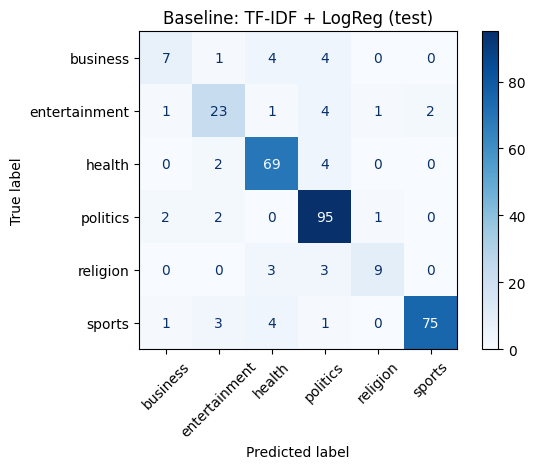

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import json

# Headline + text together
for df in (train, val, test):
    df["input"] = df["headline"].fillna("") + ". " + df["text"].fillna("")

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                      sublinear_tf=True, min_df=2)
Xtr = vec.fit_transform(train["input"])
Xva = vec.transform(val["input"])
Xte = vec.transform(test["input"])

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(Xtr, train["category"])

# Validation scores (used to compare settings)
pv = clf.predict(Xva)
print("VALIDATION  acc: %.3f  macro-F1: %.3f" % (
    accuracy_score(val["category"], pv),
    f1_score(val["category"], pv, average="macro")))

# Test scores (report these once, at the end)
pt = clf.predict(Xte)
acc = accuracy_score(test["category"], pt)
mf1 = f1_score(test["category"], pt, average="macro")
wf1 = f1_score(test["category"], pt, average="weighted")
print("TEST  acc: %.3f  macro-F1: %.3f  weighted-F1: %.3f" % (acc, mf1, wf1))
print()
print(classification_report(test["category"], pt, digits=3))

# Confusion matrix
labels = sorted(train["category"].unique())
cm = confusion_matrix(test["category"], pt, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Baseline: TF-IDF + LogReg (test)")
plt.tight_layout()
plt.savefig("cm_baseline.png", dpi=150)
plt.show()

# Save results for the experiments table
results = {"baseline_tfidf_logreg": {"accuracy": acc, "macro_f1": mf1,
                                     "weighted_f1": wf1}}
json.dump(results, open("results.json", "w"), indent=2)

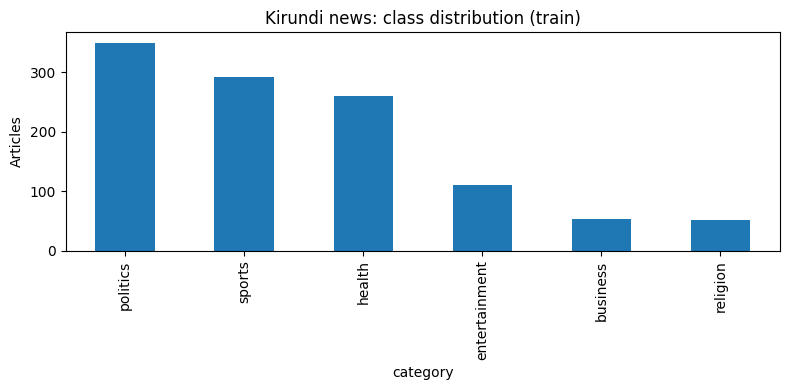

In [5]:
import matplotlib.pyplot as plt

train["category"].value_counts().plot(kind="bar", figsize=(8, 4),
                                      title="Kirundi news: class distribution (train)")
plt.ylabel("Articles")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 53.9 MB/s eta 0:00:00
Vocabulary size: 19152


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,915,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,915,400 (7.31 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,915,400 (7.31 MB)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.4557 - loss: 1.5835 - val_accuracy: 0.8176 - val_loss: 1.0640
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7466 - loss: 0.9970 - val_accuracy: 0.7547 - val_loss: 0.8502
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8165 - loss: 0.7433 - val_accuracy: 0.8679 - val_loss: 0.6206
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8174 - loss: 0.6552 - val_accuracy: 0.8113 - val_loss: 0.5648
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8532 - loss: 0.5530 - val_accuracy: 0.8679 - val_loss: 0.4782
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8702 - loss: 0.4601 - val_accuracy: 0.9119 - val_loss: 0.3996
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8747 - loss: 0.4291 - val_accuracy: 0.8616 - val_loss: 0.3978
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8970 - loss: 0.3549 - val_accuracy: 0.8428 - v

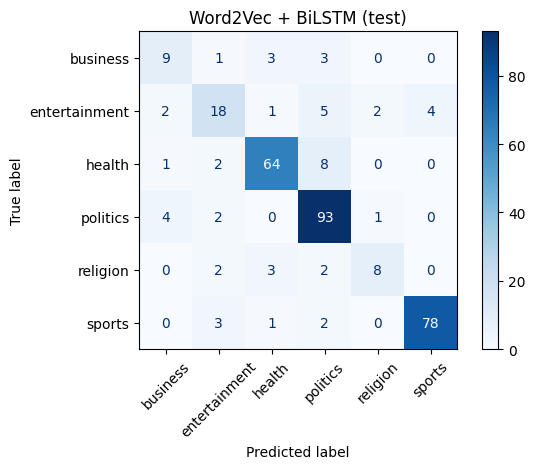

In [6]:
!pip install -q gensim

import re, json, numpy as np, tensorflow as tf
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)

# 1. Tokenize (lowercase words)
def tok(t):
    return re.findall(r"\w+", t.lower())

tr_tok = [tok(t) for t in train["input"]]
va_tok = [tok(t) for t in val["input"]]
te_tok = [tok(t) for t in test["input"]]

# 2. Train Word2Vec on TRAIN text only (no test leakage)
EMB = 100
w2v = Word2Vec(sentences=tr_tok, vector_size=EMB, window=5, min_count=2,
               sg=1, epochs=30, seed=42, workers=1)
print("Vocabulary size:", len(w2v.wv))

# 3. Word -> index (0 = padding, 1 = unknown)
word2idx = {w: i + 2 for i, w in enumerate(w2v.wv.index_to_key)}
emb_matrix = np.zeros((len(word2idx) + 2, EMB), dtype="float32")
for w, i in word2idx.items():
    emb_matrix[i] = w2v.wv[w]

MAXLEN = 400
def to_seq(tokens_list):
    seqs = [[word2idx.get(w, 1) for w in toks] for toks in tokens_list]
    return tf.keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAXLEN, padding="post", truncating="post")

Xtr, Xva, Xte = to_seq(tr_tok), to_seq(va_tok), to_seq(te_tok)

# 4. Labels
le = LabelEncoder().fit(train["category"])
ytr = le.transform(train["category"])
yva = le.transform(val["category"])
yte = le.transform(test["category"])

cw = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
class_weight = {i: w for i, w in enumerate(cw)}

# 5. Model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(emb_matrix), EMB, weights=[emb_matrix],
                              trainable=False, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(le.classes_), activation="softmax"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                         restore_best_weights=True)
hist = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=40,
                 batch_size=32, class_weight=class_weight, callbacks=[early])

# 6. Evaluate
pv = model.predict(Xva).argmax(1)
print("VALIDATION  acc: %.3f  macro-F1: %.3f" % (
    accuracy_score(yva, pv), f1_score(yva, pv, average="macro")))

pt = model.predict(Xte).argmax(1)
acc = accuracy_score(yte, pt)
mf1 = f1_score(yte, pt, average="macro")
wf1 = f1_score(yte, pt, average="weighted")
print("TEST  acc: %.3f  macro-F1: %.3f  weighted-F1: %.3f" % (acc, mf1, wf1))
print(classification_report(yte, pt, target_names=le.classes_, digits=3))

cm = confusion_matrix(yte, pt)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Word2Vec + BiLSTM (test)")
plt.tight_layout()
plt.savefig("cm_bilstm.png", dpi=150)
plt.show()

# 7. Save result next to the baseline
results = json.load(open("results.json"))
results["w2v_bilstm"] = {"accuracy": acc, "macro_f1": mf1, "weighted_f1": wf1}
json.dump(results, open("results.json", "w"), indent=2)

GPU available: True


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.361243,0.918239,0.853961
2,No log,0.521973,0.886792,0.812638
3,No log,0.696018,0.930818,0.845577
4,0.581653,0.673122,0.924528,0.862904
5,0.581653,0.551213,0.930818,0.878414
6,0.581653,0.517246,0.918239,0.859155
7,0.581653,0.687013,0.943396,0.899242
8,0.030016,0.677212,0.949686,0.910681
9,0.030016,0.676873,0.949686,0.910681
10,0.030016,0.677155,0.949686,0.910681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

VALIDATION  acc: 0.950  macro-F1: 0.911


TEST  acc: 0.916  macro-F1: 0.853  weighted-F1: 0.915
               precision    recall  f1-score   support

     business      0.611     0.688     0.647        16
entertainment      0.957     0.688     0.800        32
       health      0.914     0.987     0.949        75
     politics      0.939     0.920     0.929       100
     religion      0.765     0.867     0.812        15
       sports      0.976     0.988     0.982        84

     accuracy                          0.916       322
    macro avg      0.860     0.856     0.853       322
 weighted avg      0.920     0.916     0.915       322



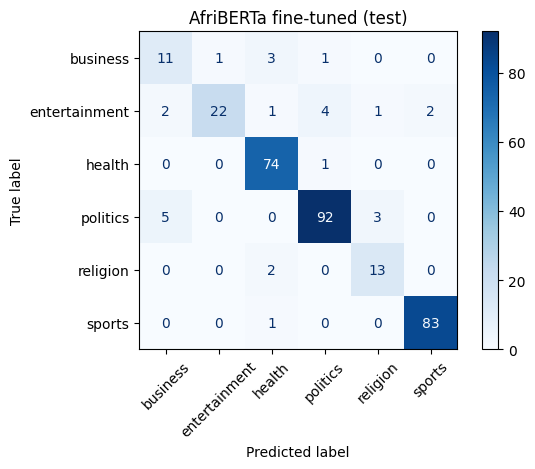

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [1]:
!pip install -q transformers datasets accelerate scikit-learn

import json, numpy as np, pandas as pd, torch
from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          set_seed)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

set_seed(42)
print("GPU available:", torch.cuda.is_available())   # must say True

# 1. Data
ds = load_dataset("masakhane/masakhanews", "run")
def prep(split):
    df = pd.DataFrame(ds[split])
    df["input"] = df["headline"].fillna("") + ". " + df["text"].fillna("")
    return df
train, val, test = prep("train"), prep("validation"), prep("test")

labels = sorted(train["category"].unique())
l2i = {l: i for i, l in enumerate(labels)}

# 2. Tokenize (long articles are cut at 512 tokens)
MODEL = "castorini/afriberta_base"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def make_ds(df):
    enc = tokenizer(df["input"].tolist(), truncation=True, max_length=512)
    return Dataset.from_dict({**enc, "labels": [l2i[c] for c in df["category"]]})

tr_ds, va_ds, te_ds = make_ds(train), make_ds(val), make_ds(test)

# 3. Class weights (same idea as the other models)
ytr = np.array([l2i[c] for c in train["category"]])
cw = torch.tensor(compute_class_weight("balanced", classes=np.arange(len(labels)),
                                       y=ytr), dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels")
        out = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            out.logits, y, weight=cw.to(out.logits.device))
        return (loss, out) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {"accuracy": accuracy_score(p.label_ids, preds),
            "macro_f1": f1_score(p.label_ids, preds, average="macro")}

# 4. Model + training settings
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL, num_labels=len(labels),
    id2label={i: l for l, i in l2i.items()}, label2id=l2i)

args = TrainingArguments(
    output_dir="afriberta_out",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=140,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    seed=42,
    report_to="none",
)

trainer = WeightedTrainer(model=model, args=args, train_dataset=tr_ds,
                          eval_dataset=va_ds,
                          data_collator=DataCollatorWithPadding(tokenizer),
                          compute_metrics=compute_metrics)
trainer.train()

# 5. Evaluate
val_pred = trainer.predict(va_ds)
print("VALIDATION  acc: %.3f  macro-F1: %.3f" % (
    accuracy_score(val_pred.label_ids, val_pred.predictions.argmax(-1)),
    f1_score(val_pred.label_ids, val_pred.predictions.argmax(-1), average="macro")))

out = trainer.predict(te_ds)
y_true, y_pred = out.label_ids, out.predictions.argmax(-1)
acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average="macro")
wf1 = f1_score(y_true, y_pred, average="weighted")
print("TEST  acc: %.3f  macro-F1: %.3f  weighted-F1: %.3f" % (acc, mf1, wf1))
print(classification_report(y_true, y_pred, target_names=labels, digits=3))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(xticks_rotation=45, cmap="Blues")
plt.title("AfriBERTa fine-tuned (test)")
plt.tight_layout()
plt.savefig("cm_afriberta.png", dpi=150)
plt.show()

# 6. Save results and the model
try:
    results = json.load(open("results.json"))
except FileNotFoundError:
    results = {}
results["afriberta"] = {"accuracy": acc, "macro_f1": mf1, "weighted_f1": wf1}
json.dump(results, open("results.json", "w"), indent=2)

trainer.save_model("afriberta_kirundi")
tokenizer.save_pretrained("afriberta_kirundi")

# Save per-example predictions for error analysis
test_out = test[["category", "headline", "text"]].copy()
test_out["predicted"] = [labels[i] for i in y_pred]
test_out.to_csv("afriberta_test_predictions.csv", index=False)